<a href="https://colab.research.google.com/github/timur262007/first-project/blob/main/hh_ru_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [60]:
df = pd.read_csv('hh ru DATASET.csv')

In [16]:
df_for_teenagers = df[df['accept_teenagers'] == True]

SyntaxError: unterminated string literal (detected at line 1) (ipython-input-3106544224.py, line 1)

In [19]:
df_for_teenagers_region = df_for_teenagers[df_for_teenagers['region_name'] == 'Новосибирская область']

In [39]:
df_for_teenagers_region['relation'] = df_for_teenagers_region['young_invitation_count'] / df_for_teenagers_region['young_response_count']
df_for_teenagers_region['relation'].fillna


/tmp/ipython-input-2344356054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_teenagers_region['relation'] = df_for_teenagers_region['young_invitation_count'] / df_for_teenagers_region['young_response_count']


<bound method NDFrame.fillna of relation
976       1.000000
1461      1.000000
2426           NaN
3603      0.250000
3713      0.113208
            ...   
266065    1.222222
266116         NaN
266969    0.075000
268320    0.500000
268637         NaN
Name: relation, Length: 467, dtype: float64>

In [42]:
df_for_teenagers_region['отношение заявок к приглашениям'] = pd.cut(df_for_teenagers_region['relation'], bins=[0.00, 0.20, 0.50, 1], labels=['низкий', 'средний', 'высокий'])

/tmp/ipython-input-3940182906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_teenagers_region['отношение заявок к приглашениям'] = pd.cut(df_for_teenagers_region['relation'], bins=[0.00, 0.20, 0.50, 1], labels=['низкий', 'средний', 'высокий'])


In [53]:
df_3 = df_for_teenagers_region.groupby('отношение заявок к приглашениям').agg({'compensation_to':'mean'}).reset_index()

/tmp/ipython-input-2814879440.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_3 = df_for_teenagers_region.groupby('отношение заявок к приглашениям').agg({'compensation_to':'mean'}).reset_index()


In [54]:
df_3

,отношение заявок к приглашениям,compensation_to
0,низкий,110400.558140
1,средний,126425.038462
2,высокий,110831.425926


Text(0.5, 1.0, 'Средняя предельная зарплата среди подававших заявки на работу(категории успешности подачи) в Новосибирской области')

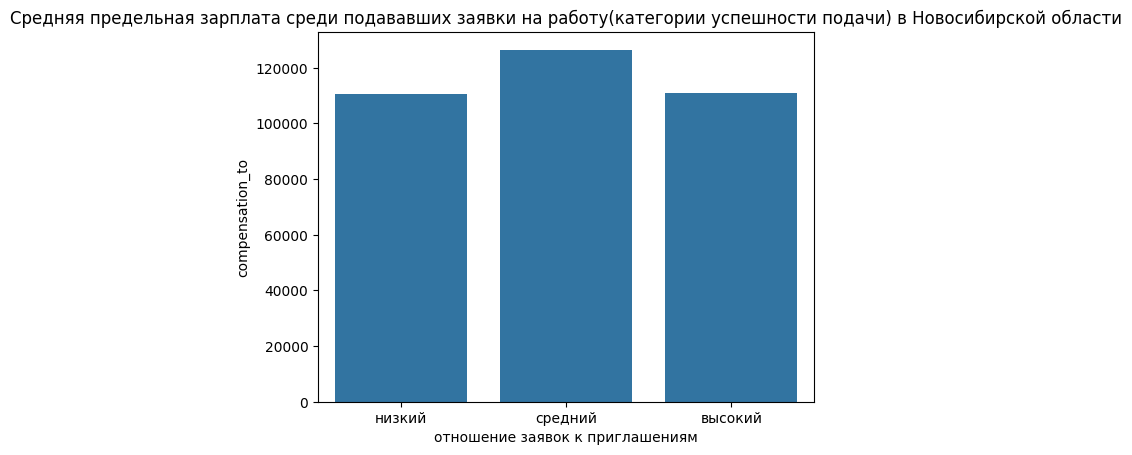

In [58]:
sns.barplot(x="отношение заявок к приглашениям", y="compensation_to", data=df_3)
plt.title('Средняя предельная зарплата среди подававших заявки на работу(категории успешности подачи) в Новосибирской области')

Text(0.5, 1.0, 'Распределение пола зарплат относительно опыта')

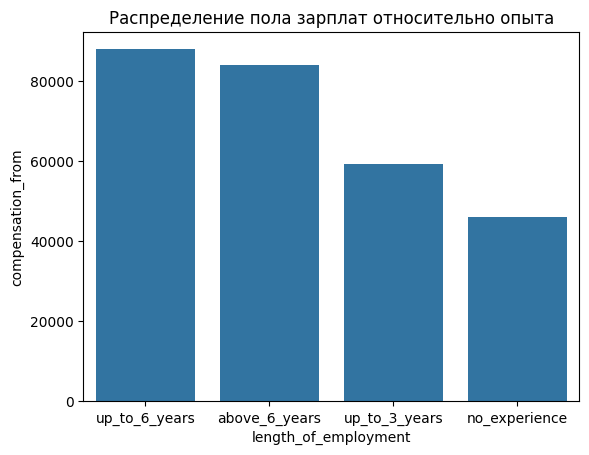

In [74]:
df_hist = df.groupby('length_of_employment')['compensation_from'].mean().reset_index().sort_values(by='compensation_from', ascending=False)
sns.barplot(x='length_of_employment', y='compensation_from', data=df_hist)
plt.title('Распределение пола зарплат относительно опыта')

In [99]:
df_primor = df[df['region_name'] == 'Приморский край']

In [106]:
df_primor1 = df_primor['specialization'].value_counts().reset_index()

Text(0.5, 1.0, 'Распределение количества вакансий')

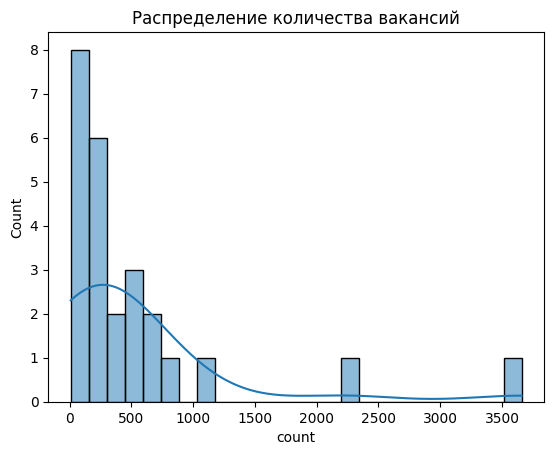

In [108]:
sns.histplot(df_primor1["count"], bins=25, kde=True)
plt.title('Распределение количества вакансий')